# BreakHis 100X Multiclass Classification



Installation of libraries

In [ ]:
!pip -q install torch torchvision scikit-learn pandas numpy matplotlib seaborn pillow tqdm openpyxl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import gc
import copy
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

## 1. Configuration

setting up the training configuration and dataset parameters. Tuning hyperparameters such as image size (224), batch size (16), epochs (20), learning rate (1e-4), and early stopping patience (5). The FREEZE_BACKBONE = False setting enables full fine-tuning of the pretrained model.

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 2
PATIENCE = 5
FREEZE_BACKBONE = False

CLASS_NAMES = [
    "adenosis",
    "ductal_carcinoma",
    "fibroadenoma",
    "lobular_carcinoma",
    "mucinous_carcinoma",
    "papillary_carcinoma",
    "phyllodes_tumor",
    "tubular_adenoma"
]

CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASS_NAMES)

VALID_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

print("Using device:", DEVICE)

Using device: cuda


Setting the pathway for the dataset

In [ ]:
MYDRIVE = "/content/drive/MyDrive"

def normalize_name(x):
    return x.lower().strip().replace(" ", "_").replace("-", "_")

def find_breakhis_100x_path(base_dir=MYDRIVE):
    candidates = []

    for root, dirs, files in os.walk(base_dir):
        for d in dirs:
            if d.lower().strip() == "100x":
                full_path = os.path.join(root, d)
                norm = full_path.lower().replace("\\", "/")
                if "classificacao_multiclasse/100x" in norm:
                    candidates.append(full_path)

    if not candidates:
        return None, []

    candidates = sorted(
        candidates,
        key=lambda p: (
            "breakhis" not in p.lower(),
            "dataset_cancer_v1" not in p.lower(),
            len(p)
        )
    )
    return candidates[0], candidates

DATASET_PATH, ALL_MATCHES = find_breakhis_100x_path()

print("Detected DATASET_PATH:", DATASET_PATH)
print("All candidate matches:")
for p in ALL_MATCHES:
    print("-", p)

if DATASET_PATH is None:
    print("\nCould not auto-detect the BreakHis 100X folder.")
    print("Folders directly in MyDrive:")
    print(os.listdir(MYDRIVE))
    raise FileNotFoundError(
        "BreakHis 100X folder was not detected automatically. "
        "Inspect the printed Drive folders and update the path if needed."
    )

DATA_ROOT = str(Path(DATASET_PATH).parent)
MAGNIFICATION_FOLDER = "100X"

print("\nDATA_ROOT:", DATA_ROOT)
print("MAGNIFICATION_FOLDER:", MAGNIFICATION_FOLDER)
print("Path exists:", os.path.exists(DATASET_PATH))

Detected DATASET_PATH: /content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X
All candidate matches:
- /content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X

DATA_ROOT: /content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse
MAGNIFICATION_FOLDER: 100X
Path exists: True


## 2. Dataset inspection

This section prints the real dataset tree so that path or folder-name problems are visible immediately.

In [ ]:
def inspect_dataset_tree(root_path, max_levels=3, max_items=8):
    root_path = Path(root_path)
    print(f"Inspecting: {root_path}\n")

    for current_root, dirs, files in os.walk(root_path):
        rel = Path(current_root).relative_to(root_path)
        depth = len(rel.parts)

        if depth > max_levels:
            continue

        indent = "    " * depth
        print(f"{indent}{Path(current_root).name}/")

        for d in sorted(dirs)[:max_items]:
            print(f"{indent}    [D] {d}")

        for f in sorted(files)[:max_items]:
            print(f"{indent}    [F] {f}")

        if len(dirs) > max_items:
            print(f"{indent}    ... {len(dirs) - max_items} more folders")
        if len(files) > max_items:
            print(f"{indent}    ... {len(files) - max_items} more files")

inspect_dataset_tree(DATASET_PATH, max_levels=3, max_items=8)

Inspecting: /content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X

100X/
    [D] adenosis
    [D] ductal_carcinoma
    [D] fibroadenoma
    [D] lobular_carcinoma
    [D] mucinous_carcinoma
    [D] papillary_carcinoma
    [D] phyllodes_tumor
    [D] tubular_adenoma
    adenosis/
        [F] SOB_B_A-14-22549AB-100-001.png
        [F] SOB_B_A-14-22549AB-100-002.png
        [F] SOB_B_A-14-22549AB-100-003.png
        [F] SOB_B_A-14-22549AB-100-004.png
        [F] SOB_B_A-14-22549AB-100-005.png
        [F] SOB_B_A-14-22549AB-100-006.png
        [F] SOB_B_A-14-22549AB-100-007.png
        [F] SOB_B_A-14-22549AB-100-008.png
        ... 105 more files
    ductal_carcinoma/
        [F] SOB_M_DC-14-10926-100-001.png
        [F] SOB_M_DC-14-10926-100-002.png
        [F] SOB_M_DC-14-10926-100-003.png
        [F] SOB_M_DC-14-10926-100-004.png
        [F] SOB_M_DC-14-10926-100-005.png
        [F] SOB_M_DC-14-10926-100-006.png
        [F] SOB_M_DC-14-10926-100-007.png

Printing the counts of the different cancers per folder

In [ ]:
def find_possible_class_folders(dataset_path):
    dataset_path = Path(dataset_path)
    folder_counter = Counter()

    for root, dirs, files in os.walk(dataset_path):
        image_count = sum(1 for f in files if Path(f).suffix.lower() in VALID_EXTS)
        if image_count > 0:
            folder_counter[Path(root).name] += image_count

    print("Possible class folders with image counts:")
    for name, count in folder_counter.most_common():
        print(f"{name}: {count}")

find_possible_class_folders(DATASET_PATH)

Possible class folders with image counts:
ductal_carcinoma: 903
fibroadenoma: 260
mucinous_carcinoma: 222
lobular_carcinoma: 170
tubular_adenoma: 150
papillary_carcinoma: 142
phyllodes_tumor: 121
adenosis: 113


##  Robust image collection

- normalizing folder names
- detecting labels from nested folders and partial matches
- printing example files if labeling fails

In [ ]:
NORMALIZED_CLASS_TO_IDX = {normalize_name(k): v for k, v in CLASS_TO_IDX.items()}

def infer_label_from_path_robust(path_str):
    parts = [normalize_name(p) for p in Path(path_str).parts]

    for part in parts:
        if part in NORMALIZED_CLASS_TO_IDX:
            return NORMALIZED_CLASS_TO_IDX[part]

    joined = "/".join(parts)
    for cls_name, cls_idx in NORMALIZED_CLASS_TO_IDX.items():
        if cls_name in joined:
            return cls_idx

    return None

def collect_breakhis_images_robust(dataset_path):
    dataset_path = Path(dataset_path)

    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

    all_files = []
    image_files = []
    samples = []
    unknown_label_files = []

    for img_path in dataset_path.rglob("*"):
        if img_path.is_file():
            all_files.append(str(img_path))

            if img_path.suffix.lower() in VALID_EXTS:
                image_files.append(str(img_path))
                label_idx = infer_label_from_path_robust(str(img_path))

                if label_idx is not None:
                    samples.append((str(img_path), label_idx))
                else:
                    unknown_label_files.append(str(img_path))

    print(f"Total files found: {len(all_files)}")
    print(f"Image files found: {len(image_files)}")
    print(f"Labeled images found: {len(samples)}")
    print(f"Images with unknown labels: {len(unknown_label_files)}")

    if len(image_files) > 0:
        print("\nExample image files:")
        for p in image_files[:10]:
            print(p)

    if len(unknown_label_files) > 0:
        print("\nExample images with unknown labels:")
        for p in unknown_label_files[:10]:
            print(p)

    if len(samples) == 0:
        raise ValueError(
            f"No labeled images found inside {dataset_path}. "
            "This usually means the folder names do not match the class names."
        )

    return samples

all_samples = collect_breakhis_images_robust(DATASET_PATH)
all_paths = [s[0] for s in all_samples]
all_labels = [s[1] for s in all_samples]

print("\nTotal labeled images found:", len(all_paths))
print("\nOverall class distribution:")
for cls_idx, count in sorted(Counter(all_labels).items()):
    print(f"{IDX_TO_CLASS[cls_idx]}: {count}")

Total files found: 2081
Image files found: 2081
Labeled images found: 2081
Images with unknown labels: 0

Example image files:
/content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X/adenosis/SOB_B_A-14-22549AB-100-020.png
/content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X/adenosis/SOB_B_A-14-22549AB-100-029.png
/content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X/adenosis/SOB_B_A-14-22549AB-100-012.png
/content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X/adenosis/SOB_B_A-14-22549AB-100-007.png
/content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X/adenosis/SOB_B_A-14-22549CD-100-035.png
/content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X/adenosis/SOB_B_A-14-22549CD-100-001.png
/content/drive/MyDrive/Breakhis dataset/dataset_cancer_v1/classificacao_multiclasse/100X/adenosis/S

## Histogram showing the distribution of the different cancer classes

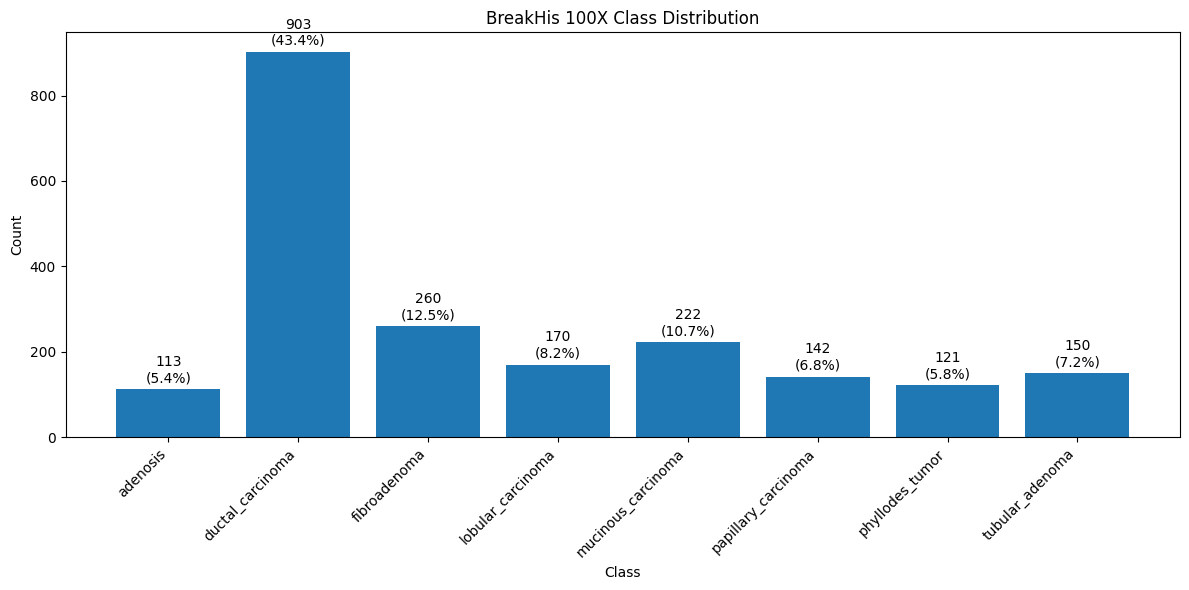

,Class,Count,Percentage
0,adenosis,113,5.430082
1,ductal_carcinoma,903,43.392600
2,fibroadenoma,260,12.493993
3,lobular_carcinoma,170,8.169149
4,mucinous_carcinoma,222,10.667948
5,papillary_carcinoma,142,6.823642
6,phyllodes_tumor,121,5.814512
7,tubular_adenoma,150,7.208073


In [ ]:
class_counts = Counter(all_labels)
plot_df = pd.DataFrame({
    "Class": [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)],
    "Count": [class_counts.get(i, 0) for i in range(NUM_CLASSES)]
})
plot_df["Percentage"] = 100 * plot_df["Count"] / max(1, plot_df["Count"].sum())

plt.figure(figsize=(12, 6))
bars = plt.bar(plot_df["Class"], plot_df["Count"])
for bar, count, pct in zip(bars, plot_df["Count"], plot_df["Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(1, plot_df["Count"].max()) * 0.01,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.title("BreakHis 100X Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(plot_df)

## 4. Train/validation/test split

In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=42,
    shuffle=True
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42,
    shuffle=True
)

print("Split sizes:")
print(f"Train: {len(train_paths)}")
print(f"Val:   {len(val_paths)}")
print(f"Test:  {len(test_paths)}")

Split sizes:
Train: 1456
Val:   312
Test:  313


## 5. Dataset and transformation / augmentation
Resize: Images are resized to 224×224.
RandomHorizontalFlip: Flips images randomly to increase data diversity.
RandomRotation(20): Rotates images slightly (±20°).
ColorJitter: Changes brightness, contrast, saturation to simulate staining variations.
ToTensor(): Converts image to numerical format (0–1 scale).
Normalize(): Standardizes pixel values for ImageNet compatibility.
Data augmentation  applied to prevent overfitting and improve generalization.


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class BreakHisDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        with Image.open(image_path) as img:
            image = img.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

## Setting and loading the training set to get the data distribution within the training set

In [ ]:
train_dataset = BreakHisDataset(train_paths, train_labels, transform=train_transform)
val_dataset = BreakHisDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = BreakHisDataset(test_paths, test_labels, transform=eval_transform)

train_class_counts = Counter(train_labels)
class_weights = {cls: 1.0 / count for cls, count in train_class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]

train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

pin_memory_flag = True if DEVICE.type == "cuda" else False

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory_flag
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory_flag
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory_flag
)

print("Training class distribution:")
for cls_idx, count in sorted(train_class_counts.items()):
    print(f"{IDX_TO_CLASS[cls_idx]}: {count}")

Training class distribution:
adenosis: 79
ductal_carcinoma: 632
fibroadenoma: 182
lobular_carcinoma: 119
mucinous_carcinoma: 155
papillary_carcinoma: 99
phyllodes_tumor: 85
tubular_adenoma: 105


## 6. Models

ResNet50, DenseNet121 and EfficientNetB0 are used
Dropout rate is set at 0.3 to prevent overfitting,
Linear layer  outputs 8 classes of the tumors adapting the  model to classification task,
Freeze-Backbone freezes all layers except the final classifier whilst earlier layers keep pretrained knowledge


In [ ]:
def build_model(model_name, num_classes):
    model_name = model_name.lower()

    if model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

        if FREEZE_BACKBONE:
            for name, param in model.named_parameters():
                if not name.startswith("fc"):
                    param.requires_grad = False

    elif model_name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)
        in_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

        if FREEZE_BACKBONE:
            for name, param in model.named_parameters():
                if not name.startswith("classifier"):
                    param.requires_grad = False

    elif model_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

        if FREEZE_BACKBONE:
            for name, param in model.named_parameters():
                if not name.startswith("classifier"):
                    param.requires_grad = False

    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    return model

## 7. Training and evaluation

 model training and evaluation process. Training the model  (train_one_epoch), evaluating performance on validation data without updating weights (evaluate_model), and tracking metrics like loss, accuracy, F1-score, and ROC-AUC. Training runs multiple epochs, applies early stopping, and saves the best-performing model based on validation F1-score.

In [ ]:
@torch.no_grad()
def evaluate_model(model, loader, criterion, device, num_classes):
    model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        total_loss += loss.item() * images.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    try:
        roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
    except Exception:
        roc_auc = np.nan

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "roc_auc_macro_ovr": roc_auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

def train_model(model_name, train_loader, val_loader, device, num_classes):
    print("=" * 60)
    print(f"Training model: {model_name}")
    print("=" * 60)

    model = build_model(model_name, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=1e-4)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    patience_counter = 0
    history = []

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = evaluate_model(model, val_loader, criterion, device, num_classes)

        record = {
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_precision_macro": train_metrics["precision_macro"],
            "train_recall_macro": train_metrics["recall_macro"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision_macro": val_metrics["precision_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "val_f1_macro": val_metrics["f1_macro"],
            "val_roc_auc_macro_ovr": val_metrics["roc_auc_macro_ovr"]
        }
        history.append(record)

        print(
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Train F1: {train_metrics['f1_macro']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val F1: {val_metrics['f1_macro']:.4f} | "
            f"Val AUC: {val_metrics['roc_auc_macro_ovr']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_model_wts)
    history_df = pd.DataFrame(history)

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return model, history_df

## 8. Training and comparing models

In [ ]:
MODEL_NAMES = [
    "resnet50",
    "densenet121",
    "efficientnet_b0"
]

trained_models = {}
histories = []
summary_rows = []

for model_name in MODEL_NAMES:
    start_time = time.time()

    model, history_df = train_model(
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        num_classes=NUM_CLASSES
    )

    criterion = nn.CrossEntropyLoss()
    best_val_metrics = evaluate_model(model, val_loader, criterion, DEVICE, NUM_CLASSES)

    elapsed = time.time() - start_time

    trained_models[model_name] = model
    history_df["model"] = model_name
    histories.append(history_df)

    summary_rows.append({
        "model": model_name,
        "val_loss": best_val_metrics["loss"],
        "val_accuracy": best_val_metrics["accuracy"],
        "val_precision_macro": best_val_metrics["precision_macro"],
        "val_recall_macro": best_val_metrics["recall_macro"],
        "val_f1_macro": best_val_metrics["f1_macro"],
        "val_roc_auc_macro_ovr": best_val_metrics["roc_auc_macro_ovr"],
        "training_time_seconds": round(elapsed, 2)
    })

    torch.save(model.state_dict(), f"{model_name}_robust_breakhis_100x.pth")

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

results_df = pd.DataFrame(summary_rows).sort_values(
    by="val_f1_macro", ascending=False
).reset_index(drop=True)

print("\nValidation comparison:")
display(results_df)

results_df.to_csv("model_comparison_robust_breakhis_100x.csv", index=False)

best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]

print(f"\nBest model selected: {best_model_name}")

Training model: resnet50

Epoch 1/20


Train Loss: 1.7921 | Train F1: 0.3383 | Val Loss: 1.5417 | Val F1: 0.4620 | Val AUC: 0.8927

Epoch 2/20


Train Loss: 1.0331 | Train F1: 0.6706 | Val Loss: 0.8839 | Val F1: 0.6688 | Val AUC: 0.9463

Epoch 3/20


Train Loss: 0.6261 | Train F1: 0.7899 | Val Loss: 0.6306 | Val F1: 0.7815 | Val AUC: 0.9684

Epoch 4/20


Train Loss: 0.4859 | Train F1: 0.8428 | Val Loss: 0.5409 | Val F1: 0.8065 | Val AUC: 0.9776

Epoch 5/20


...

Train Loss: 0.1630 | Train F1: 0.9392 | Val Loss: 0.2372 | Val F1: 0.9213 | Val AUC: 0.9947

Epoch 19/20


Train Loss: 0.1709 | Train F1: 0.9432 | Val Loss: 0.2823 | Val F1: 0.8830 | Val AUC: 0.9933

Epoch 20/20


Train Loss: 0.1270 | Train F1: 0.9631 | Val Loss: 0.2735 | Val F1: 0.9020 | Val AUC: 0.9944

Validation comparison:


,model,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc_macro_ovr,training_time_seconds
0,efficientnet_b0,0.216930,0.932692,0.921320,0.933143,0.926224,0.996059,408.17
1,densenet121,0.236422,0.932692,0.923822,0.920601,0.919799,0.994963,429.84
2,resnet50,0.296087,0.907051,0.906773,0.919207,0.907572,0.991653,324.46



Best model selected: efficientnet_b0


## Ploting the F1-score curves to compare the models

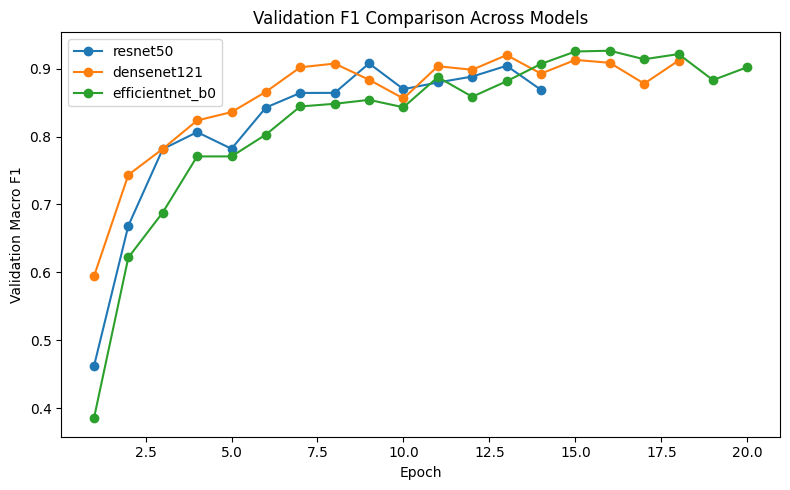

In [ ]:
history_all = pd.concat(histories, ignore_index=True)

plt.figure(figsize=(8, 5))
for model_name in MODEL_NAMES:
    sub = history_all[history_all["model"] == model_name]
    plt.plot(sub["epoch"], sub["val_f1_macro"], marker="o", label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.title("Validation F1 Comparison Across Models")
plt.legend()
plt.tight_layout()
plt.savefig("validation_f1_comparison_robust.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Test set evaluation

Using performance metrics (Loss, accuracy, precision, recall, F1-score, ROC-AUC to evaluate the model performances

In [ ]:
criterion = nn.CrossEntropyLoss()

print("="*70)
print("FINAL TEST PERFORMANCE FOR ALL MODELS")
print("="*70)

test_results = []

for model_name, model in trained_models.items():

    test_metrics = evaluate_model(model, test_loader, criterion, DEVICE, NUM_CLASSES)

    print("\n" + "-"*60)
    print(f"Model: {model_name}")
    print("-"*60)

    print(f"Test Loss            : {test_metrics['loss']:.4f}")
    print(f"Test Accuracy        : {test_metrics['accuracy']:.4f}")
    print(f"Test Precision Macro : {test_metrics['precision_macro']:.4f}")
    print(f"Test Recall Macro    : {test_metrics['recall_macro']:.4f}")
    print(f"Test F1 Macro        : {test_metrics['f1_macro']:.4f}")
    print(f"Test ROC-AUC Macro   : {test_metrics['roc_auc_macro_ovr']:.4f}")

    test_results.append({
        "model": model_name,
        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision_macro": test_metrics["precision_macro"],
        "test_recall_macro": test_metrics["recall_macro"],
        "test_f1_macro": test_metrics["f1_macro"],
        "test_auc_macro": test_metrics["roc_auc_macro_ovr"]
    })

# Convert to dataframe
test_results_df = pd.DataFrame(test_results).sort_values(
    by="test_f1_macro", ascending=False
).reset_index(drop=True)

print("\n")
print("="*70)
print("TEST SET COMPARISON")
print("="*70)

display(test_results_df)


FINAL TEST PERFORMANCE FOR ALL MODELS

------------------------------------------------------------
Model: resnet50
------------------------------------------------------------
Test Loss            : 0.2429
Test Accuracy        : 0.9073
Test Precision Macro : 0.8952
Test Recall Macro    : 0.9052
Test F1 Macro        : 0.8984
Test ROC-AUC Macro   : 0.9949

------------------------------------------------------------
Model: densenet121
------------------------------------------------------------
Test Loss            : 0.2669
Test Accuracy        : 0.9042
Test Precision Macro : 0.9081
Test Recall Macro    : 0.8957
Test F1 Macro        : 0.8999
Test ROC-AUC Macro   : 0.9936

------------------------------------------------------------
Model: efficientnet_b0
------------------------------------------------------------
Test Loss            : 0.2547
Test Accuracy        : 0.8914
Test Precision Macro : 0.8813
Test Recall Macro    : 0.8902
Test F1 Macro        : 0.8845
Test ROC-AUC Macro   : 0.

,model,test_loss,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_auc_macro
0,densenet121,0.266918,0.904153,0.908120,0.895719,0.899851,0.993629
1,resnet50,0.242928,0.907348,0.895239,0.905233,0.898408,0.994942
2,efficientnet_b0,0.254668,0.891374,0.881264,0.890166,0.884461,0.993409


## Tumor classification reports

In [ ]:
print("="*70)
print("CLASSIFICATION REPORTS FOR ALL MODELS")
print("="*70)

all_classification_reports = {}

for model_name, model in trained_models.items():

    test_metrics = evaluate_model(model, test_loader, criterion, DEVICE, NUM_CLASSES)

    print("\n" + "="*60)
    print(f"MODEL: {model_name}")
    print("="*60)

    report = classification_report(
        test_metrics["y_true"],
        test_metrics["y_pred"],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )

    print(report)

    all_classification_reports[model_name] = report


CLASSIFICATION REPORTS FOR ALL MODELS

MODEL: resnet50
                     precision    recall  f1-score   support

           adenosis     0.8947    1.0000    0.9444        17
   ductal_carcinoma     0.9542    0.9191    0.9363       136
       fibroadenoma     0.8780    0.9231    0.9000        39
  lobular_carcinoma     0.6875    0.8462    0.7586        26
 mucinous_carcinoma     0.9062    0.8529    0.8788        34
papillary_carcinoma     0.9000    0.8571    0.8780        21
    phyllodes_tumor     0.9412    0.8889    0.9143        18
    tubular_adenoma     1.0000    0.9545    0.9767        22

           accuracy                         0.9073       313
          macro avg     0.8952    0.9052    0.8984       313
       weighted avg     0.9130    0.9073    0.9089       313


MODEL: densenet121
                     precision    recall  f1-score   support

           adenosis     1.0000    0.9412    0.9697        17
   ductal_carcinoma     0.9065    0.9265    0.9164       136
      

## Confusion Matrix for the models to see where the models made classification errors

CONFUSION MATRICES FOR ALL MODELS


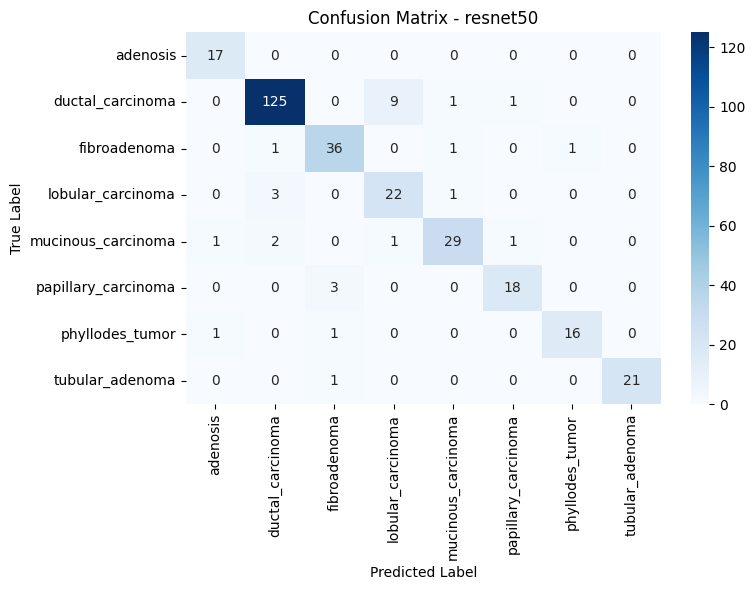

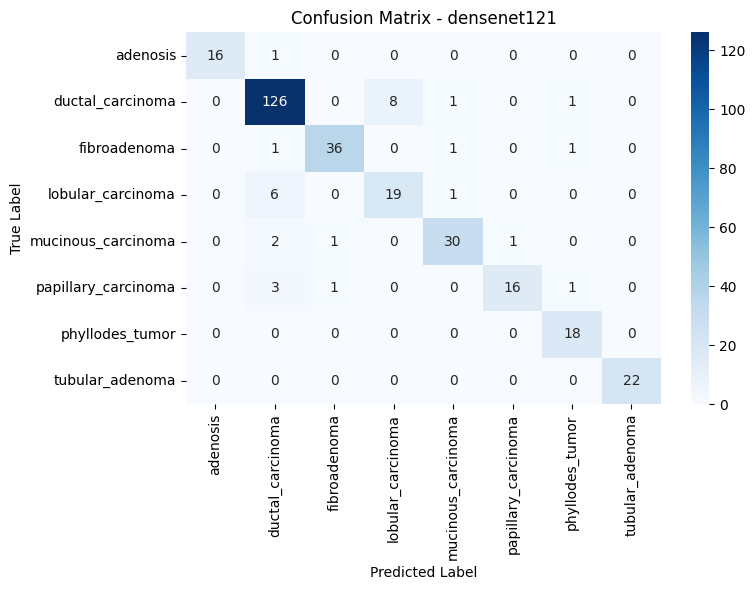

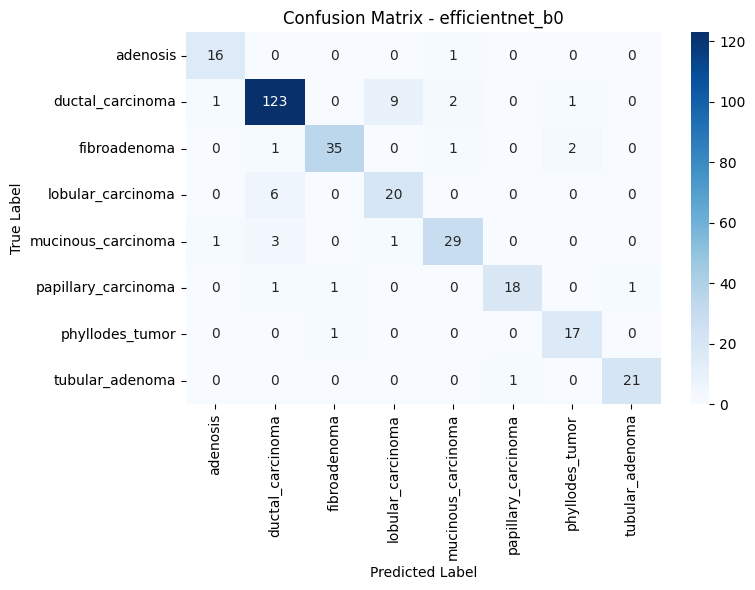

In [ ]:
print("="*70)
print("CONFUSION MATRICES FOR ALL MODELS")
print("="*70)

all_conf_matrices = {}

for model_name, model in trained_models.items():

    test_metrics = evaluate_model(model, test_loader, criterion, DEVICE, NUM_CLASSES)
    cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])
    all_conf_matrices[model_name] = cm

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{model_name}.png", dpi=300, bbox_inches="tight")
    plt.show()


# model test predictions for each tumor class

In [ ]:
print("="*70)
print("GENERATING TEST PREDICTIONS FOR ALL MODELS")
print("="*70)

prediction_dfs = {}

for model_name, model in trained_models.items():

    test_metrics = evaluate_model(model, test_loader, criterion, DEVICE, NUM_CLASSES)

    pred_df = pd.DataFrame({
        "true_label_index": test_metrics["y_true"],
        "predicted_label_index": test_metrics["y_pred"],
        "true_label_name": [IDX_TO_CLASS[i] for i in test_metrics["y_true"]],
        "predicted_label_name": [IDX_TO_CLASS[i] for i in test_metrics["y_pred"]]
    })

    prediction_dfs[model_name] = pred_df

    file_name = f"test_predictions_{model_name}_breakhis_100x.csv"
    pred_df.to_csv(file_name, index=False)

    print(f"\nSaved predictions for {model_name}: {file_name}")
    display(pred_df.head())


GENERATING TEST PREDICTIONS FOR ALL MODELS

Saved predictions for resnet50: test_predictions_resnet50_breakhis_100x.csv


,true_label_index,predicted_label_index,true_label_name,predicted_label_name
0,1,1,ductal_carcinoma,ductal_carcinoma
1,2,2,fibroadenoma,fibroadenoma
2,4,4,mucinous_carcinoma,mucinous_carcinoma
3,1,1,ductal_carcinoma,ductal_carcinoma
4,1,1,ductal_carcinoma,ductal_carcinoma



Saved predictions for densenet121: test_predictions_densenet121_breakhis_100x.csv


,true_label_index,predicted_label_index,true_label_name,predicted_label_name
0,1,1,ductal_carcinoma,ductal_carcinoma
1,2,2,fibroadenoma,fibroadenoma
2,4,4,mucinous_carcinoma,mucinous_carcinoma
3,1,1,ductal_carcinoma,ductal_carcinoma
4,1,1,ductal_carcinoma,ductal_carcinoma



Saved predictions for efficientnet_b0: test_predictions_efficientnet_b0_breakhis_100x.csv


,true_label_index,predicted_label_index,true_label_name,predicted_label_name
0,1,1,ductal_carcinoma,ductal_carcinoma
1,2,2,fibroadenoma,fibroadenoma
2,4,4,mucinous_carcinoma,mucinous_carcinoma
3,1,1,ductal_carcinoma,ductal_carcinoma
4,1,1,ductal_carcinoma,ductal_carcinoma


Plotting ROC-Curves for the models

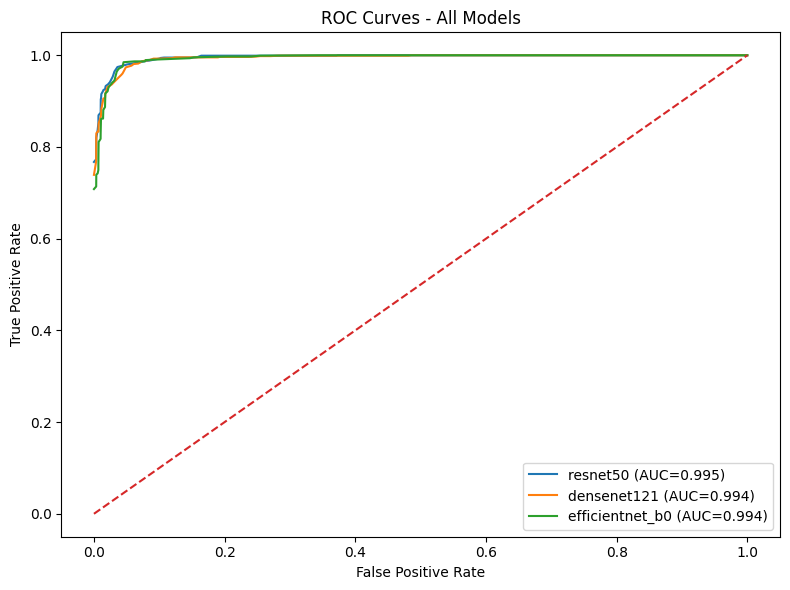

,model,macro_auc
0,resnet50,0.995184
1,densenet121,0.993967
2,efficientnet_b0,0.993760


In [ ]:
# ROC curves for all models
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
roc_rows = []

for model_name, model in trained_models.items():
    m = evaluate_model(model, test_loader, criterion, DEVICE, NUM_CLASSES)
    y_true_bin = label_binarize(m["y_true"], classes=np.arange(NUM_CLASSES))

    fpr, tpr = {}, {}
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], m["y_prob"][:, i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= NUM_CLASSES

    macro_auc = auc(all_fpr, mean_tpr)
    roc_rows.append({"model": model_name, "macro_auc": macro_auc})
    plt.plot(all_fpr, mean_tpr, label=f"{model_name} (AUC={macro_auc:.3f})")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend()
plt.tight_layout()
plt.show()

roc_df = pd.DataFrame(roc_rows).sort_values("macro_auc", ascending=False)
display(roc_df)

## Plotting learning and validation curves

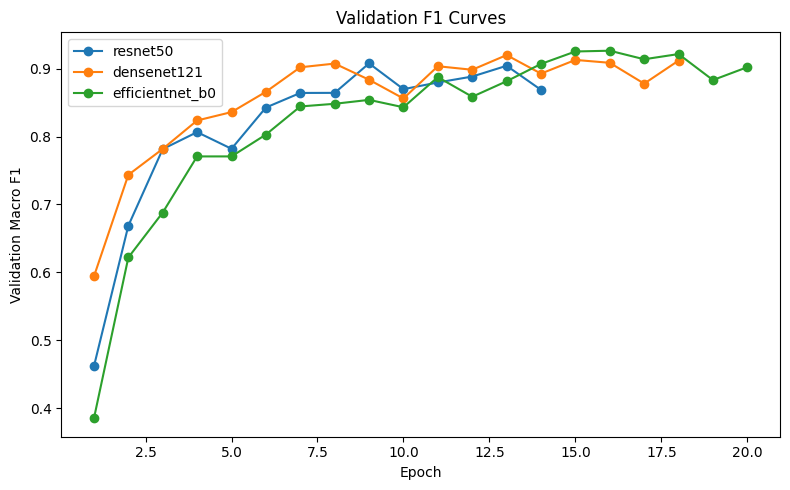

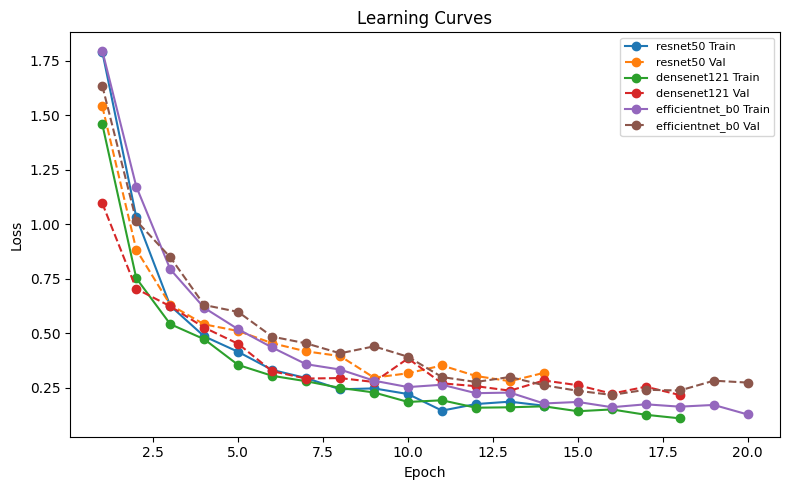

In [ ]:
# Validation and learning curves
history_all = pd.concat(histories, ignore_index=True)

# Validation F1
plt.figure(figsize=(8,5))
for model_name in history_all["model"].unique():
    sub = history_all[history_all["model"] == model_name]
    plt.plot(sub["epoch"], sub["val_f1_macro"], marker="o", label=model_name)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.title("Validation F1 Curves")
plt.legend()
plt.tight_layout()
plt.show()

# Train vs Val loss
plt.figure(figsize=(8,5))
for model_name in history_all["model"].unique():
    sub = history_all[history_all["model"] == model_name]
    plt.plot(sub["epoch"], sub["train_loss"], marker="o", label=f"{model_name} Train")
    plt.plot(sub["epoch"], sub["val_loss"], marker="o", linestyle="--", label=f"{model_name} Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Setting up Grad-CAM helper and displaying Grad-CAM to see the areas/ features the model used to make decision

In [ ]:
# Helper for grad-CAM for the best model
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

gradcam_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

def get_target_layer(model, model_name):
    if "resnet" in model_name:
        return model.layer4[-1]
    elif "densenet" in model_name:
        return model.features[-1]
    else:
        return model.features[-1]

class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.layer = layer
        self.grad = None
        self.act = None
        self.fh = layer.register_forward_hook(lambda m,i,o: setattr(self, "act", o.detach()))
        self.bh = layer.register_full_backward_hook(lambda m,gi,go: setattr(self, "grad", go[0].detach()))

    def __call__(self, x):
        self.model.zero_grad()
        out = self.model(x)
        cls = out.argmax(dim=1).item()
        out[:, cls].backward()

        w = self.grad[0].mean(dim=(1,2))
        cam = sum(w[i] * self.act[0][i] for i in range(len(w)))
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam.cpu().numpy(), cls

    def close(self):
        self.fh.remove()
        self.bh.remove()

In [ ]:
# Display Grad-CAM
def show_gradcam(model, model_name, image_path, true_label=None):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    x = gradcam_transform(img).unsqueeze(0).to(DEVICE)

    cam_obj = GradCAM(model, get_target_layer(model, model_name))
    cam, pred = cam_obj(x)
    cam_obj.close()

    img_np = np.array(img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    cam_img = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE))) / 255.0

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cam_img, cmap="jet")
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(img_np)
    plt.imshow(cam_img, cmap="jet", alpha=0.45)
    title = f"Pred: {IDX_TO_CLASS[pred]}"
    if true_label is not None:
        title += f"\nTrue: {true_label}"
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

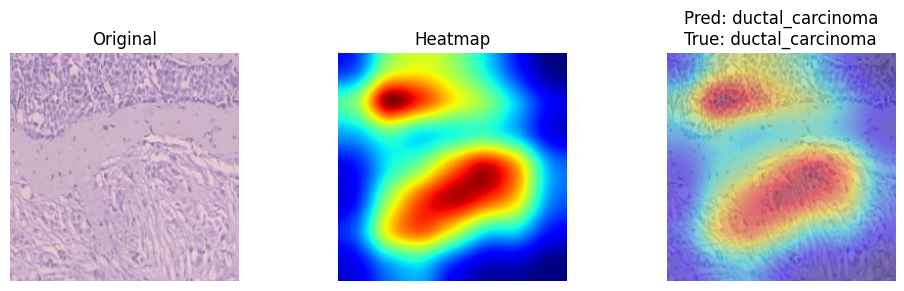

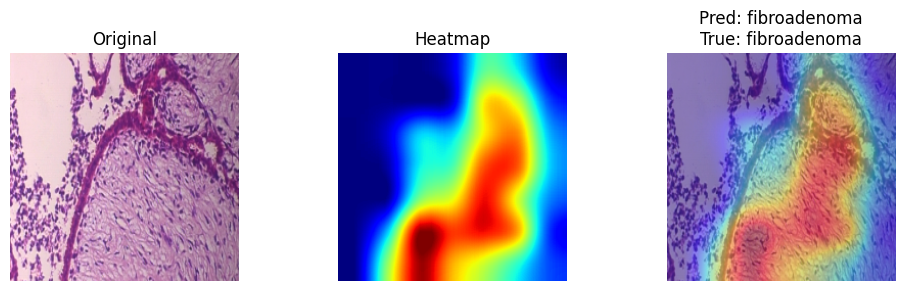

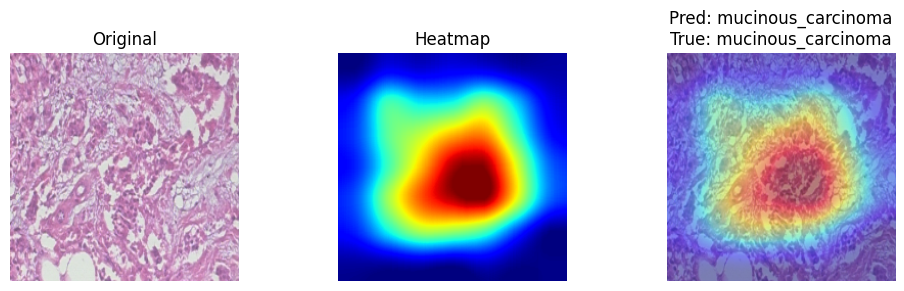

In [ ]:
# Try on a few images
for i in range(3):
    show_gradcam(
        model=best_model,
        model_name=best_model_name,
        image_path=test_paths[i],
        true_label=IDX_TO_CLASS[test_labels[i]]
    )

## Grad-CAM of misclassified images

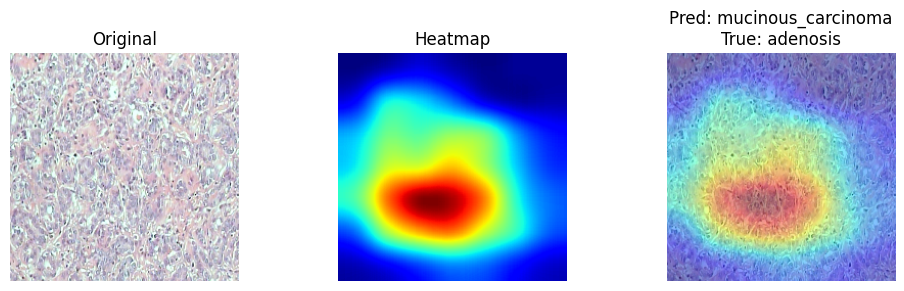

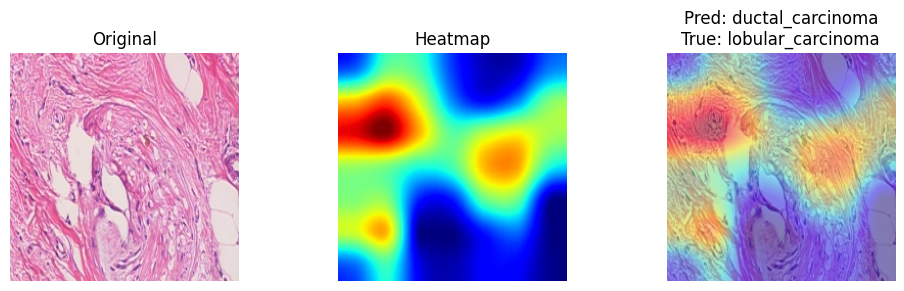

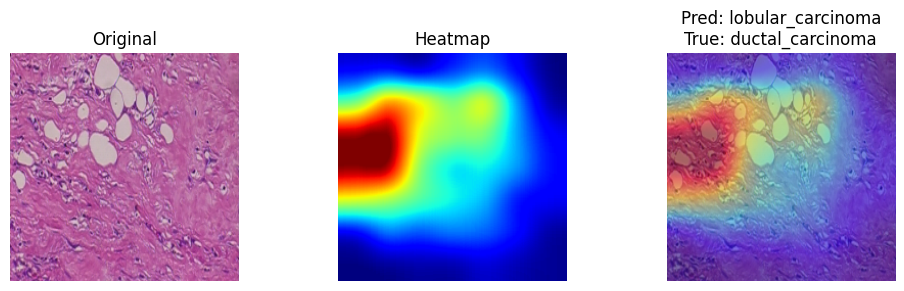

In [ ]:
# Try on misclassified images only
m = evaluate_model(best_model, test_loader, criterion, DEVICE, NUM_CLASSES)
mis_idx = np.where(m["y_true"] != m["y_pred"])[0]

for i in mis_idx[:3]:
    show_gradcam(
        model=best_model,
        model_name=best_model_name,
        image_path=test_paths[i],
        true_label=IDX_TO_CLASS[test_labels[i]]
    )
